In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import re

# ────────────────────────────────────────────────────────────────────────────
# LAYOUT EVENT AGGREGATION: Show start-end periods for consecutive layout events
# ────────────────────────────────────────────────────────────────────────────
def extract_node_id(details_str):
    """Extract nodeId from details JSON string"""
    if pd.isna(details_str):
        return None
    # Extract nodeId using regex
    match = re.search(r"'nodeId'\s*:\s*'([^']+)'", str(details_str))
    if not match:
        match = re.search(r'"nodeId"\s*:\s*"([^"]+)"', str(details_str))
    return match.group(1) if match else None


def aggregate_layout_events(df, time_gap_threshold=5.0):
    """Aggregate truly consecutive layout events by nodeId to show start-end periods

    Args:
        df: DataFrame with events
        time_gap_threshold: Maximum seconds between events to consider them consecutive
    """
    layout_event_names = [
        "layout.node.moved",
        "layoutboard.node.resizable.resized",
        "`layoutboard.node.resizable`",
    ]

    aggregated = []

    # Process each id_group separately
    for id_group in df["id_group"].unique():
        group_df = df[df["id_group"] == id_group].copy()
        group_df = group_df.sort_values("timestamp").reset_index(drop=True)

        # Find consecutive sequences of layout events for each nodeId
        i = 0
        while i < len(group_df):
            row = group_df.iloc[i]

            # Skip non-layout events
            if row["event"] not in layout_event_names:
                i += 1
                continue

            # Extract nodeId for this layout event
            node_id = extract_node_id(row["details"])
            if pd.isna(node_id):
                i += 1
                continue

            # Start a consecutive sequence
            sequence_start = i
            sequence_events = [row]

            # Look ahead to find consecutive layout events for same nodeId
            j = i + 1
            while j < len(group_df):
                next_row = group_df.iloc[j]

                # If it's not a layout event for the same node, break
                if (
                    next_row["event"] not in layout_event_names
                    or extract_node_id(next_row["details"]) != node_id
                ):
                    break

                # # Check time gap
                # time_diff = (next_row["timestamp"] - sequence_events[-1]["timestamp"]).total_seconds()
                # if time_diff > time_gap_threshold:
                #     break

                sequence_events.append(next_row)
                j += 1

            # Process the found sequence
            if len(sequence_events) == 1:
                # Single event, keep as is
                event_row = sequence_events[0]
                aggregated.append(
                    {
                        "id_group": id_group,
                        "nodeId": node_id,
                        "event": f"layout.{event_row['event'].split('.')[1]}.{event_row['event'].split('.')[2]}",
                        "timestamp": event_row["timestamp"],
                        "seq_idx": None,
                        "is_start": True,
                        "is_end": True,
                        "duration": 0,
                        "event_count": 1,
                    }
                )
            else:
                # Multiple consecutive events, create start-end pair
                first = sequence_events[0]
                last = sequence_events[-1]
                duration = (last["timestamp"] - first["timestamp"]).total_seconds()

                # Start marker
                aggregated.append(
                    {
                        "id_group": id_group,
                        "nodeId": node_id,
                        "event": "layout.start",
                        "timestamp": first["timestamp"],
                        "seq_idx": None,
                        "is_start": True,
                        "is_end": False,
                        "duration": duration,
                        "event_count": len(sequence_events),
                    }
                )

                # # End marker
                # aggregated.append(
                #     {
                #         "id_group": id_group,
                #         "nodeId": node_id,
                #         "event": "layout.end",
                #         "timestamp": last["timestamp"],
                #         "seq_idx": None,
                #         "is_start": False,
                #         "is_end": True,
                #         "duration": duration,
                #         "event_count": len(sequence_events),
                #     }
                # )

            # Move to next event after this sequence
            i = sequence_start + len(sequence_events)

    return pd.DataFrame(aggregated)

In [2]:
import pandas as pd
import ast, json
import numpy as np

def parse_details(details_str):
    if details_str is None or (isinstance(details_str, float) and pd.isna(details_str)):
        return {}
    if isinstance(details_str, dict):
        return details_str
    if isinstance(details_str, str):
        try:
            return json.loads(details_str)
        except Exception:
            pass
        try:
            return ast.literal_eval(details_str)
        except Exception:
            return {}
    return {}

# ====== 설정 ======
INPUT_CSV = "csv_log/Study2-OOPT_filtered_all.csv"  # 원본 CSV 경로
OUTPUT_CSV = "csv_log/Study2-OOPT_filtered_all.csv"  # 수정본 저장 경로

# 매핑 사전
label_map = {
    "class_instances_reset": "class.instances_reset",
    "instance_created_from_detection": "instance.created_from_detection",
    "layout_board.new_box_positioned": "instance.created_from_text",
}

# ====== 실행 ======
df = pd.read_csv(INPUT_CSV)

# 'event'라는 컬럼이 있다고 가정
df["event"] = df["event"].replace(label_map)
df["id_group"].unique()
# 2) ★ instance.updated 세분화: text / graph (둘 다면 우선순위는 text로 처리)
if "details" in df.columns:
    det = df["details"].apply(parse_details)
    text_changed  = det.apply(lambda d: bool(d.get("text_changed", False)))
    graph_changed = det.apply(lambda d: bool(d.get("graph_changed", False)))
    is_updated    = df["event"].eq("instance.updated")

    # (둘 다 True인 경우 → text 우선; 필요시 'both'로 바꾸세요)
    df.loc[is_updated & text_changed,  "event"] = "instance.updated.text"
    df.loc[is_updated & ~text_changed & graph_changed, "event"] = "instance.updated.graph"
    # (둘 다 False면 그대로 'instance.updated' 유지)

df.to_csv(OUTPUT_CSV, index=False)
df["id_group"].unique()
# df_all = df.copy()
# df = df_all.copy()

if "timestamp" in df.columns:
    if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["id_group", "timestamp"]).copy()
else:
    df = df.sort_values(["id_group"]).copy()

# Separate layout and non-layout events
non_layout_events = df[
    ~df["event"].isin(["layout.node.moved", "layoutboard.node.resizable.resized"])
].copy()
layout_aggregated = aggregate_layout_events(df)

# Combine and assign sequence indices
all_events = []

for id_group in sorted(df["id_group"].unique()):
    print("id", id_group)
    # Get non-layout events for this group
    group_non_layout = non_layout_events[
        non_layout_events["id_group"] == id_group
    ].copy()
    group_layout = layout_aggregated[layout_aggregated["id_group"] == id_group].copy()

    # Combine and sort by timestamp
    group_events = []

    for _, row in group_non_layout.iterrows():
        group_events.append(
            {
                "id_group": id_group,
                "event": row["event"],
                "timestamp": row["timestamp"],
                "is_layout": False,
                "is_start": False,
                "is_end": False,
                "duration": 0,
                "event_count": 1,
            }
        )

    for _, row in group_layout.iterrows():
        group_events.append(
            {
                "id_group": id_group,
                "event": row["event"],
                "timestamp": row["timestamp"],
                "is_layout": True,
                "is_start": row["is_start"],
                "is_end": row["is_end"],
                "duration": row["duration"],
                "event_count": row["event_count"],
            }
        )

    # Sort by timestamp and assign sequence indices
    group_events.sort(key=lambda x: x["timestamp"])
    for i, event in enumerate(group_events):
        event["seq_idx"] = i
        all_events.append(event)

# Create final dataframe
df_final = pd.DataFrame(all_events)
df_final = df_final[
    (df_final["event"] != "layout.node.moved")
    & (df_final["event"] != "layout.node.resizable")
]

df.to_csv(OUTPUT_CSV, index=False)

print(f"Total events after aggregation: {len(df_final)}")
print(
    f"Layout start/end pairs: {len(df_final[df_final['event'].str.startswith('layout.')])}"
)

id 1
id 2
id 3
id 4
id 5
id 6
Total events after aggregation: 785
Layout start/end pairs: 144


In [3]:
# df = pd.read_csv("csv_log/Study2-OOPT_filtered_all.csv")
df_final["id_group"].unique()

array([1, 2, 3, 4, 5, 6])

In [4]:
# ------------------------------------------------------------
# 3) scene_saved 기준으로 잘라 Participant{pid}-scene{slot} 라벨 부여
#    - slot_number는 scene_saved 이벤트의 details에만 존재
#    - 구간: (prev_scene_saved, current_scene_saved]  (이전 직후 ~ 현재 포함)
#    - 라벨은 current_scene_saved의 slot_number 사용
# ------------------------------------------------------------

# 3-1) scene_saved 마커만 추출하고 slot_number 파싱
def extract_slot_from_details(d):
    # details가 dict가 아닐 수도 있으니 안전하게 처리
    if not isinstance(d, dict):
        try:
            d = parse_details(d)
        except Exception:
            print("Exception during parsing details")
            d = {}
    return d.get("slotNumber", None)

scene_markers = (
    df[df["event"] == "scene_saved"]
    .copy()
    .sort_values(["id_group", "timestamp"])
)
scene_markers["slot_number"] = scene_markers["details"].apply(extract_slot_from_details)
# slot_number가 없는 마커는 제외(안전장치)
scene_markers = scene_markers[scene_markers["slot_number"].notna()].copy()

# 3-2) df_final(시각화용 집계 결과)에 scene_label/scene_slot 붙이기
#      df_final은 details가 없으니, 시간 구간 매칭으로 라벨링한다.
labeled_segments = []
for pid in sorted(df_final["id_group"].unique()):
    gf = df_final[df_final["id_group"] == pid].sort_values("timestamp").copy()
    gm = scene_markers[scene_markers["id_group"] == pid].sort_values("timestamp").copy()
    if gm.empty or gf.empty:
        continue

    # 이전 컷 시점(초기엔 그룹 시작 전)
    prev_t = gf["timestamp"].min() - pd.Timedelta(seconds=1)

    for _, m in gm.iterrows():
        cur_t = m["timestamp"]
        slot = int(m["slot_number"])  # scene 번호

        # (prev_t, cur_t] 범위의 이벤트를 이번 scene으로 라벨링
        mask = (gf["timestamp"] > prev_t) & (gf["timestamp"] <= cur_t)
        seg = gf[mask].copy()
        if not seg.empty:
            seg["scene_slot"] = slot
            seg["scene_label"] = f"P{pid}-scene{slot}"
            labeled_segments.append(seg)

        prev_t = cur_t  # 다음 구간을 위해 업데이트

# 3-3) 병합 및 저장
if labeled_segments:
    df_by_scene = pd.concat(labeled_segments, ignore_index=True)
else:
    df_by_scene = df_final.copy()
    df_by_scene["scene_slot"] = np.nan
    df_by_scene["scene_label"] = None

OUTPUT_SCENE_CSV = "csv_log/Study2-OOPT_by_scene.csv"
df_by_scene.to_csv(OUTPUT_SCENE_CSV, index=False)

print("Scene 단위 분할 저장:", OUTPUT_SCENE_CSV)
df_final = df_by_scene.copy()
df_by_scene

Scene 단위 분할 저장: csv_log/Study2-OOPT_by_scene.csv


,id_group,event,timestamp,is_layout,is_start,is_end,duration,event_count,seq_idx,scene_slot,scene_label
0,1,instance.created_from_text,2000-01-01 08:33:16,False,False,False,0.0,1,0,1,P1-scene1
1,1,class.created,2000-01-01 08:34:45,False,False,False,0.0,1,2,1,P1-scene1
2,1,instance.created_from_class,2000-01-01 08:35:11,False,False,False,0.0,1,3,1,P1-scene1
3,1,layout.start,2000-01-01 08:35:22,True,True,False,6.0,4,4,1,P1-scene1
4,1,layout.start,2000-01-01 08:35:29,True,True,False,3.0,3,5,1,P1-scene1
...,...,...,...,...,...,...,...,...,...,...,...
717,6,layout.start,2000-01-01 02:25:11,True,True,False,12.0,2,159,6,P6-scene6
718,6,api.generate_image.succeeded,2000-01-01 02:25:50,False,False,False,0.0,1,160,6,P6-scene6
719,6,scene_saved,2000-01-01 02:25:58,False,False,False,0.0,1,161,6,P6-scene6
720,6,scene_saved,2000-01-01 02:25:59,False,False,False,0.0,1,162,5,P6-scene5


In [5]:
# ────────────────────────────────────────────────────────────────────────────
# VISUALIZATION SETUP WITH IMPROVED COLORS AND GROUPING
# ────────────────────────────────────────────────────────────────────────────

# Updated color scheme with layout events
base_colors = {
    'class': plt.cm.Blues,      # Class events - Blue
    'instance': plt.cm.Reds,    # Instance events - Red  
    'object': plt.cm.Greens,    # Object events - Green
    'edge': plt.cm.Purples,     # Other events - Purple
    'layout': plt.cm.Greys,   # Layout events - Orange (NEW)
    'api': plt.cm.Wistia,        # API events - Grey
}

# Categorize events with improved grouping
event_types = sorted(df_final['event'].unique())
event_to_group = {}
for ev in event_types:
    if ev == 'api.generate_image.succeeded':
        event_to_group[ev] = 'api'
    elif ev.startswith('layout.'):
        event_to_group[ev] = 'layout'
    elif ev.startswith('class'):
        event_to_group[ev] = 'class'
    elif ev.startswith('instance'):
        event_to_group[ev] = 'instance'
    elif ev.startswith('object_node'):
        event_to_group[ev] = 'object'
    else:
        event_to_group[ev] = 'edge'

# Assign colors
event_to_color = {}
for group in set(event_to_group.values()):
    group_events = [ev for ev, g in event_to_group.items() if g == group]
    cmap = base_colors[group]
    n = len(group_events)
    colors = [cmap(x) for x in np.linspace(0.9, 0.3, max(n, 1))]
    for i, ev in enumerate(group_events):
        event_to_color[ev] = colors[i] if n > 1 else cmap(0.7)

# Enhanced marker mapping with same color but different shapes for instance creation
marker_map = {
    # Class events
    'class.created': 'o',
    'class.updated': 'o', 
    'class.instances_reset': 'o',
    
    # Instance events - SAME COLOR, DIFFERENT SHAPES
    'instance.created_from_class': 'o',      # Diamond
    'instance.created_from_text': 's',       # Circle
    'instance.created_from_detection': '^',   # Triangle
    'instance.updated.text': 's',             # Square
    'instance.updated.graph': 's',             # Square

    # Layout events - distinct markers
    'layout.start': 's',                     # Start marker
    'layout.end': 's',                       # End marker
    'layout.moved': 's',                     # Individual move
    'layout.resized': 'v',                   # Individual resize
    
    # Object events
    'object_node.extract.confirmed': 's',    # Hexagon
    
    # API events
    'api.generate_image.succeeded': '*',     # Star
}

alpha_map = {
    'instance.created_from_class': 0.95,
    'instance.created_from_text': 0.95, 
    'instance.created_from_detection': 0.95,
    'instance.updated.text': 0.65,
    'instance.updated.graph': 0.65,
    'layout.start': 0.7,
    'layout.end': 0.7,
    'api.generate_image.succeeded': 1
}

# Make instance creation events same color
instance_creation_color = base_colors['instance'](0.7)
for event in ['instance.created_from_class', 'instance.created_from_text', 'instance.created_from_detection']:
    if event in event_to_color:
        event_to_color[event] = instance_creation_color

# Make instance creation events same color
layout_color = base_colors['layout'](0.7)
for event in ['layout.start', 'layout.end', 'layout.moved', 'layout.resized']:
    if event in event_to_color:
        event_to_color[event] = layout_color
        
api_color = base_colors['api'](0.3)
event_to_color['api.generate_image.succeeded'] = api_color
        
# 표시용 그룹 이름
group_display = {
    "class": "Class-related",
    "instance": "Instance",
    "object": "Object",
    "layout": "Layout",
    "edge": "Edge",
    "api": "API",
    "other": "Etc."
}

# 표시용 이벤트 이름
event_display = {
    "class.created": "Create Class",
    "class.updated": "Update Class",
    "class.instances_reset": "Reset Class Instances",

    "instance.created_from_class": "Create Instance from Class",
    "instance.created_from_text": "Create Instance from Text",
    "instance.created_from_detection": "Create Instance from Detection",
    "instance.updated.text": "Update Instance",
    "instance.updated.graph": "Update Instance",

    "layout.start": "Update Layout",
    "layout.end": "Layout End",
    "layout.moved": "Move",
    "layout.resized": "Resize",

    "object_node.extract.confirmed": "Object Extract",

    "api.generate_image.succeeded": "Image Generated",
    "relationship_node.created": "Create Edge",
    "relationship_node.edited": "Update Edge"
}

from matplotlib.lines import Line2D

def make_group_event_legend(
    ax,
    event_types,
    event_to_group,
    event_to_color,
    marker_map,
    group_display,
    event_display,
    title="Event Groups + Events",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    group_order=None,          # ✅ 그룹 순서 지정
    event_order=None           # ✅ (옵션) 그룹 내 이벤트 순서 지정
):
    """'그룹이름 – 이벤트이름' 조합으로 커스텀 범례 생성 (그룹/이벤트 순서 지정 가능)"""
    # 1) 그룹 순서 랭크 만들기
    if group_order is None:
        # 지정 없으면 group_display 키 순서 사용
        group_order = list(group_display.keys())
    group_rank = {g: i for i, g in enumerate(group_order)}

    # 2) (옵션) 이벤트 순서 랭크 만들기
    # event_order 예시:
    # {"class": ["class.created", "class.updated"], "instance": ["instance.created_from_class", ...]}
    event_rank = {}
    if event_order:
        for g, ev_list in event_order.items():
            event_rank.update({ev: i for i, ev in enumerate(ev_list)})

    # 3) 정렬용 키 함수
    def sort_key(ev):
        g = event_to_group.get(ev, "other")
        gk = group_rank.get(g, 10**6)
        # 이벤트 순서가 주어지면 우선, 아니면 표시용 이름으로 알파벳 정렬
        ek = event_rank.get(ev, 10**6)
        ename = event_display.get(ev, ev)
        return (gk, ek, ename)

    # 4) 정렬된 이벤트 순회
    handles, labels, seen = [], [], set()
    for ev in sorted(event_types, key=sort_key):
        grp_key = event_to_group.get(ev, "other")
        grp_name = group_display.get(grp_key, grp_key)
        ev_name  = event_display.get(ev, ev)
        label = f"{grp_name} – {ev_name}"
        if label in seen:
            continue
        seen.add(label)

        color = event_to_color.get(ev, "black")
        marker = marker_map.get(ev, "s")
        handles.append(Line2D([0], [0], marker=marker, linestyle="",
                              markerfacecolor=color, markeredgecolor=color,
                              markersize=10, alpha=1.0))
        labels.append(label)

    leg = ax.legend(handles, labels, title=title, loc=loc, bbox_to_anchor=bbox_to_anchor)
    return leg


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df_all = df_final.copy()

# 각 id_group별로 첫 이벤트를 0초로 맞추기
if "timestamp" in df_all.columns:
    if not pd.api.types.is_datetime64_any_dtype(df_all["timestamp"]):
        df_all["timestamp"] = pd.to_datetime(df_all["timestamp"])
    df_all["time_norm"] = df_all.groupby("scene_label")["timestamp"].transform(
        lambda x: (x - x.min()).dt.total_seconds()
    )
    x = df_all["time_norm"]
else:
    x = df_all.index

# id_group별로 y축 배치
id_groups_sorted = sorted(df_all["scene_label"].unique())
id_group_to_y = {id_: i for i, id_ in enumerate(id_groups_sorted)}
y = df_all["scene_label"].map(id_group_to_y)

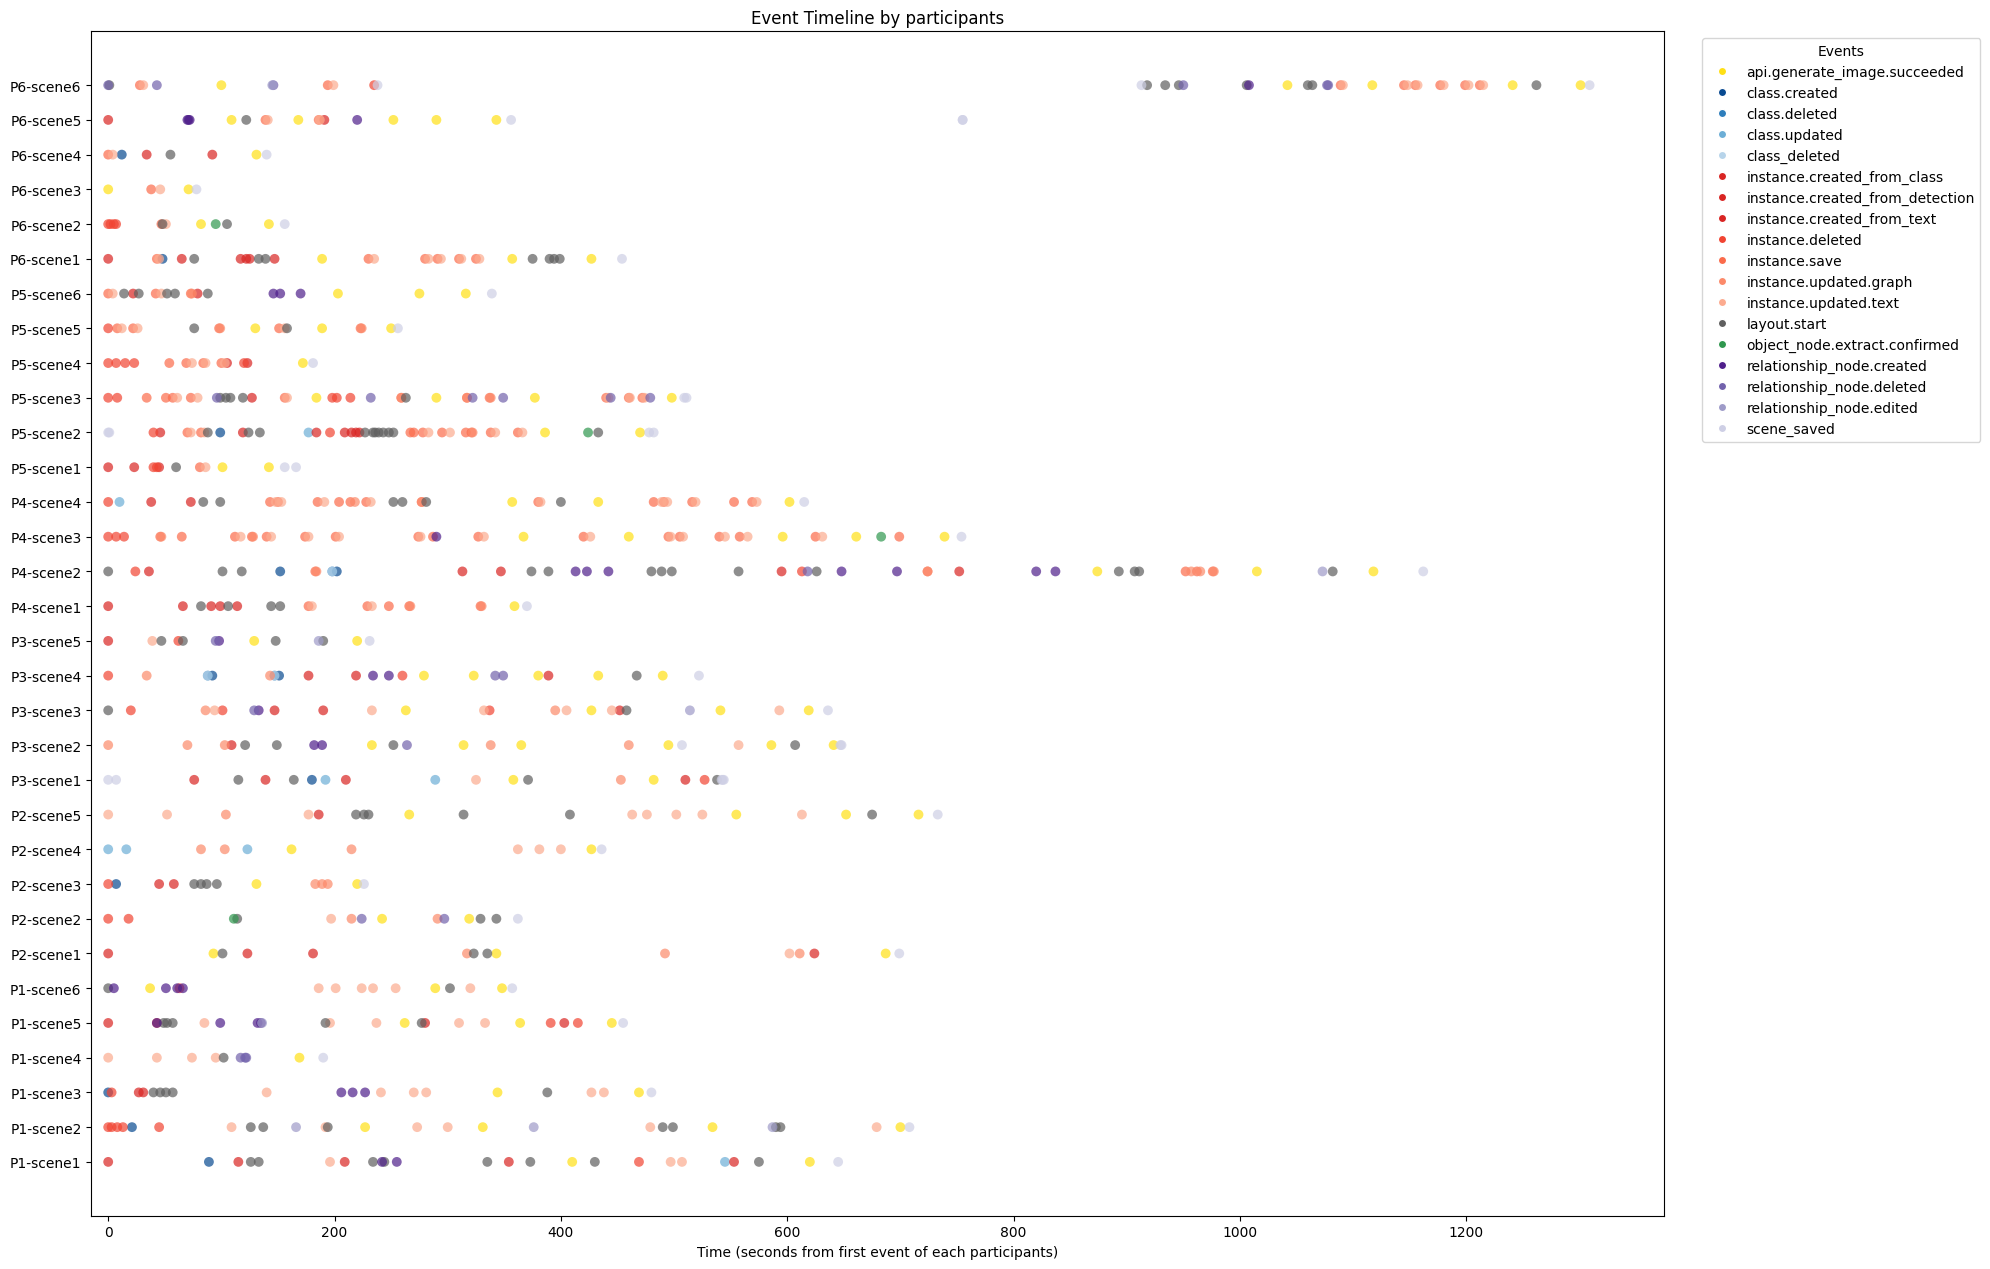

In [7]:
from matplotlib.lines import Line2D
import numpy as np

plt.figure(figsize=(20, max(6, len(id_groups_sorted) * 0.4)))
rng = np.random.default_rng(42)

legend_elems = []  # legend 수동 구성

for ev in event_types:
    mask = df_all["event"] == ev
    group = [g for e, g in zip(event_types, event_to_group) if e == ev][0]
    y_jitter = y[
        mask
    ]  # .to_numpy(dtype=float) + rng.uniform(-0.05, 0.05, size=mask.sum())

    # 기본 스타일
    scatter_args = dict(
        x=x[mask],
        y=y_jitter,
        color=event_to_color[ev],
        marker="o",
        s=50,
        alpha=0.7,
        edgecolors="none",
        linewidths=0,
    )

    plt.scatter(**scatter_args)

    # legend entry 생성
    legend_elems.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=event_to_color[ev],
            markersize=(
                6
                if ev
                in [
                    "class.created",
                    "class.updated",
                    "instance.created_from_class",
                    "instance.updated",
                ]
                else 6
            ),
            label=ev,
        )
    )

plt.xlabel("Time (seconds from first event of each participants)")
plt.yticks(list(id_group_to_y.values()), list(id_group_to_y.keys()))
plt.title("Event Timeline by participants")

plt.legend(
    handles=legend_elems, bbox_to_anchor=(1.02, 1), loc="upper left", title="Events"
)
plt.xlim(left=-15)
plt.tight_layout()
plt.show()

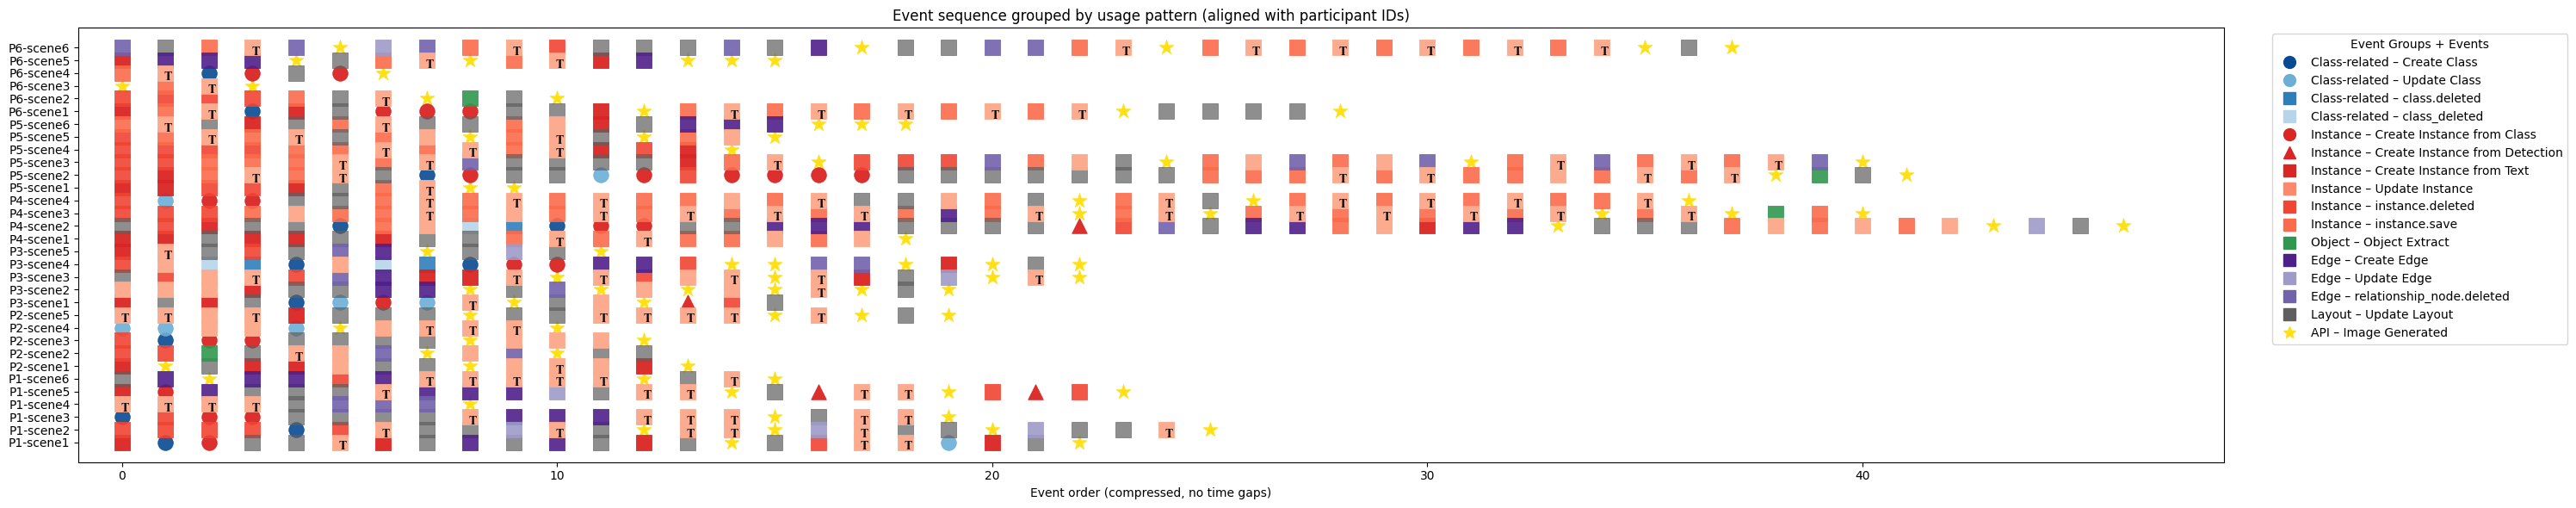

In [8]:
df_sorted = df_all.sort_values(["scene_label", "time_norm"]).copy()
df_sorted = df_sorted[df_sorted["event"] != "scene_saved"]

# 2) 참가자별 순서 인덱스 부여 (반복 이벤트 포함) - use existing seq_idx or create new
# if "seq_idx" not in df_sorted.columns:
df_sorted["seq_idx"] = df_sorted.groupby("scene_label").cumcount()
# 그냥 Participant ID가 Y-axis
df_sorted["y_axis"] = df_sorted["scene_label"]

# 3) 플롯
event_types = sorted(df_sorted["event"].unique())

# ---- Plot ----
fig, ax = plt.subplots(figsize=(30, 6))  # ← plt.figure 대신 이렇게 쓰면 ax 확보

event_types = sorted(df_sorted["event"].unique())

# id_group별로 y축 배치
id_groups_sorted = sorted(df_all["scene_label"].unique())
id_group_to_y = {id_: i for i, id_ in enumerate(id_groups_sorted)}

# 1) 기존 루프에선 updated.* 두 이벤트는 건너뛰기
for ev in event_types:
    if ev in ('instance.updated.text', 'instance.updated.graph'):
        continue  # 아래에서 따로 레이어링으로 그림
    mask  = df_sorted['event'] == ev
    marker = marker_map.get(ev, 's')
    alpha  = alpha_map.get(ev, 0.9)
    ax.scatter(
        df_sorted.loc[mask, 'seq_idx'],
        df_sorted.loc[mask, 'y_axis'],
        color=event_to_color[ev],
        marker=marker, s=160, alpha=alpha,
         linewidths=0.6
    )

# 1) updated.* 두 이벤트는 기본 사각형 바탕부터 깔기
upd_mask = df_sorted['event'].isin(['instance.updated.text', 'instance.updated.graph'])
base_color = event_to_color.get('instance.updated.text', event_to_color.get('instance.created_from_text'))
ax.scatter(
    df_sorted.loc[upd_mask, 'seq_idx'],
    df_sorted.loc[upd_mask, 'y_axis'],
    marker='s', s=160, alpha=1,
    facecolors=base_color, linewidths=0.6,
    zorder=2
)

# 2) text: 작은 'T'를 우하단에 배치 (offset: +x, -y)
m_text = df_sorted['event'].eq('instance.updated.text')

from matplotlib import font_manager as fm
import matplotlib.patheffects as pe

# 사용할 폰트 선택 (Times New Roman 없으면 Times → STIXGeneral로 폴백)
t_font = 'Times New Roman'
try:
    fm.findfont(t_font, fallback_to_default=False)
except:
    t_font = 'Times'
    try:
        fm.findfont(t_font, fallback_to_default=False)
    except:
        t_font = 'STIXGeneral'

# 우하단 'T' 오버레이
for x, y in df_sorted.loc[m_text, ['seq_idx', 'y_axis']].to_numpy():
    txt = ax.annotate(
        'T', (x, y),
        textcoords='offset points', xytext=(-1, 1),  # 우하단
        ha='left', va='top',
        fontsize=10, fontweight='bold', color='black',
        fontname=t_font,          # ← 여기!
        zorder=5
    )

ax.set_xlabel("Event order (compressed, no time gaps)")
ax.set_title("Event sequence grouped by usage pattern (aligned with participant IDs)")
ax.set_xlim(left=-1)

# 원하는 그룹 순서 지정
group_order = ["class", "instance", "object", "edge", "layout",  "api"]

make_group_event_legend(
    ax,
    event_types=event_types,
    event_to_group=event_to_group,
    event_to_color=event_to_color,
    marker_map=marker_map,
    group_display=group_display,
    event_display=event_display,
    title="Event Groups + Events",
    loc="upper left", bbox_to_anchor=(1.02, 1),
    group_order=group_order,    # ✅ 여기!
)

# Y는 Participant ID
ax.set_yticks(df_sorted["y_axis"].unique())
ax.set_yticklabels(df_sorted["scene_label"].unique())
plt.tight_layout()
plt.show()

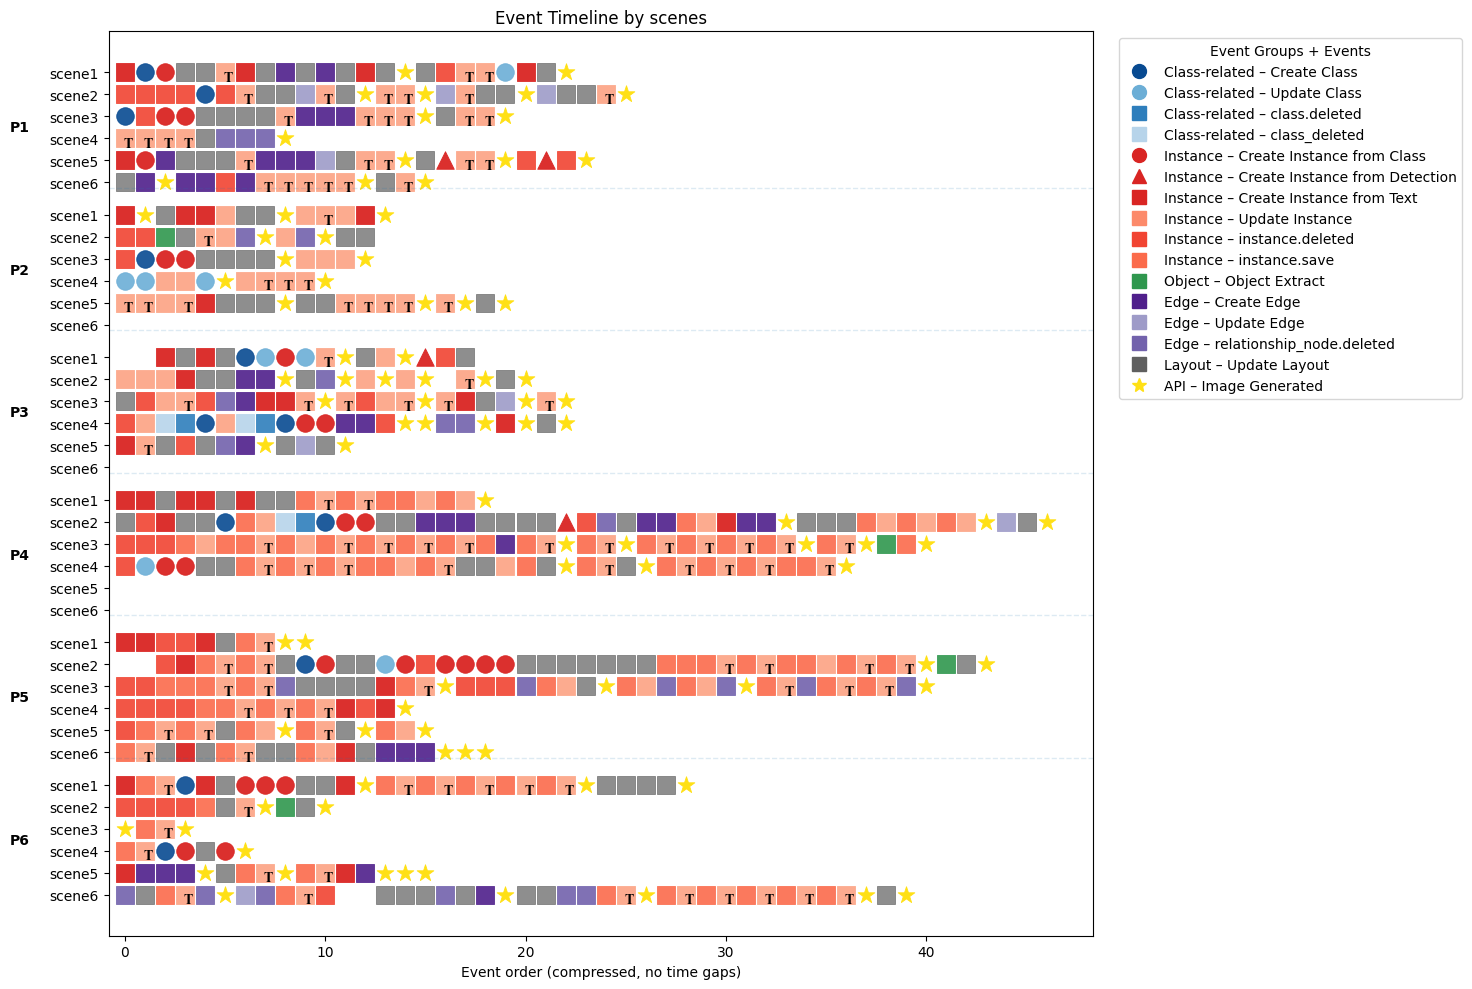

In [21]:
# ─────────────────────────────────────────────────────────
# 준비: participant, scene_slot, x(참여자 기준 경과초) 계산
# df_all: ["id_group","timestamp","event","scene_slot", ...] 가정
# event_to_color, event_types 등은 기존 그대로 사용
# ─────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1) 참여자 정렬, 씬 개수/라벨
participants = sorted(df_all["id_group"].unique())
K = int(df_all["scene_slot"].max())   # scene 개수 (예: 6)
scene_labels = [f"scene{i}" for i in range(1, K+1)]

# 2) x축: 참여자별 첫 이벤트 기준 경과초
df_all = df_all.copy()
df_all["timestamp"] = pd.to_datetime(df_all["timestamp"])
first_ts = df_all.groupby("id_group")["timestamp"].transform("min")
df_all["seq_idx"] = df_all.groupby("scene_label").cumcount()

# df_all["t_rel"] = (df_all["timestamp"] - first_ts).dt.total_seconds()

# 3) y축: (참여자 블록 오프셋) + (scene_slot)
#    block_height = K + gap 로 해서 참여자 사이 간격을 줌
gap = 0.5
block_height = K + gap
pid_to_block = {pid: i for i, pid in enumerate(participants)}  # 0,1,2...
df_all["y_scene_only"] = df_all.apply(
    lambda r: pid_to_block[r["id_group"]]*block_height + (int(r["scene_slot"]) if not pd.isna(r["scene_slot"]) else 0),
    axis=1
)

# 4) 실제 그리기
fig, ax = plt.subplots(figsize=(15, max(10, len(participants)*0.9)))
# 1) 기존 루프에선 updated.* 두 이벤트는 건너뛰기
for ev in event_types:
    if ev in ('instance.updated.text', 'instance.updated.graph'):
        continue  # 아래에서 따로 레이어링으로 그림
    mask  = df_all['event'] == ev
    marker = marker_map.get(ev, 's')
    alpha  = alpha_map.get(ev, 0.9)
    ax.scatter(
        df_all.loc[mask, 'seq_idx'],
        df_all.loc[mask, 'y_scene_only'],
        color=event_to_color[ev],
        marker=marker, s=160, alpha=alpha,
         linewidths=0.6
    )


# 1) updated.* 두 이벤트는 기본 사각형 바탕부터 깔기
upd_mask = df_all['event'].isin(['instance.updated.text', 'instance.updated.graph'])
base_color = event_to_color.get('instance.updated.text', event_to_color.get('instance.created_from_text'))
ax.scatter(
    df_all.loc[upd_mask, 'seq_idx'],
    df_all.loc[upd_mask, 'y_scene_only'],
    marker='s', s=160, alpha=1,
    facecolors=base_color, linewidths=0.6,
    zorder=2
)

# 2) text: 작은 'T'를 우하단에 배치 (offset: +x, -y)
m_text = df_all['event'].eq('instance.updated.text')

from matplotlib import font_manager as fm
import matplotlib.patheffects as pe

# 사용할 폰트 선택 (Times New Roman 없으면 Times → STIXGeneral로 폴백)
t_font = 'Times New Roman'
try:
    fm.findfont(t_font, fallback_to_default=False)
except:
    t_font = 'Times'
    try:
        fm.findfont(t_font, fallback_to_default=False)
    except:
        t_font = 'STIXGeneral'

# 우하단 'T' 오버레이
for x, y in df_all.loc[m_text, ['seq_idx', 'y_scene_only']].to_numpy():
    txt = ax.annotate(
        'T', (x, y),
        textcoords='offset points', xytext=(-1, 1),  # 우하단
        ha='left', va='top',
        fontsize=10, fontweight='bold', color='black',
        fontname=t_font,          # ← 여기!
        zorder=5
    )

# 5) ytick: 각 참여자 블록 안에서 scene1..sceneK만 반복 표시
yticks = []
yticklabels = []
for i, pid in enumerate(participants):
    base = i*block_height
    for s in range(1, K+1):
        yticks.append(base + s)
        yticklabels.append(scene_labels[s-1])

# 6) 왼쪽에 Participant 라벨(‘P1’, ‘P2’, …)을 블록 중앙에 한 번만 표기
for i, pid in enumerate(participants):
    y_center = i*block_height + (K+1)/2.0
    ax.text(-0.08, y_center, f"P{pid}", va="center", ha="right", weight="bold",
            transform=ax.get_yaxis_transform())  # 축 좌표계로 왼쪽 바깥에 배치

# 7) 보조선: 참여자 블록 경계선
for i in range(1, len(participants)):
    ysep = i*block_height - gap/2
    ax.axhline(ysep, linestyle="--", alpha=0.15, linewidth=1)

# 8) 축/범례 세팅
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
ax.set_xlabel("Event order (compressed, no time gaps)")
ax.set_title("Event Timeline by scenes")

# 원하는 그룹 순서 지정
group_order = ["class", "instance", "object", "edge", "layout",  "api"]

make_group_event_legend(
    ax,
    event_types=event_types,
    event_to_group=event_to_group,
    event_to_color=event_to_color,
    marker_map=marker_map,
    group_display=group_display,
    event_display=event_display,
    title="Event Groups + Events",
    loc="upper left", bbox_to_anchor=(1.02, 1),
    group_order=group_order,    # ✅ 여기!
)
# y축 거꾸로
ax.invert_yaxis()
ax.set_xlim(left=-0.8)

plt.tight_layout()
plt.show()


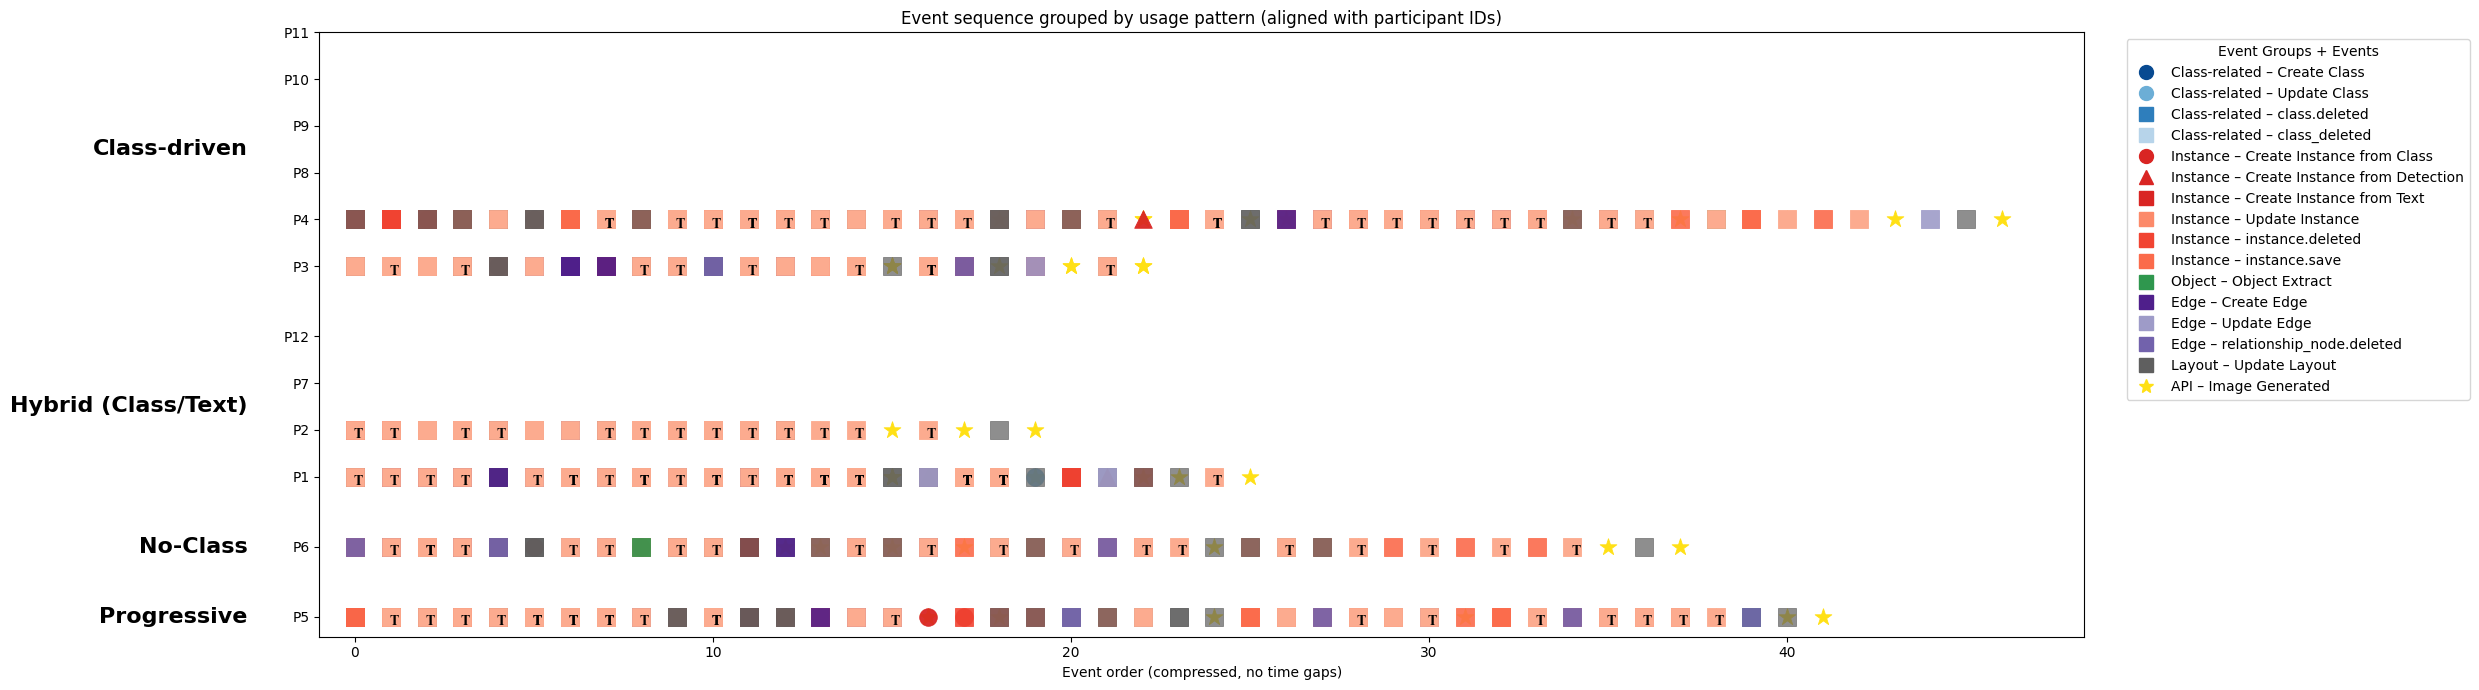

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# ---- 1) 그룹 매핑 ----
group_map = {
    3: "Class-driven",
    4: "Class-driven",
    8: "Class-driven",
    9: "Class-driven",
    10: "Class-driven",
    11: "Class-driven",
    1: "Hybrid (Class/Text)",
    2: "Hybrid (Class/Text)",
    7: "Hybrid (Class/Text)",
    12: "Hybrid (Class/Text)",
    5: "Progressive",
    6: "No-Class",
}
df_sorted["group_label"] = df_sorted["id_group"].map(group_map)

# ---- 참가자 순서 (그룹 포함) ----
group_order = ["Class-driven", "Hybrid (Class/Text)", "No-Class", "Progressive"]
group_order.reverse()

yticks = []
yticklabels = []
y_val = 0
group_centers = {}

for g in group_order:
    members = sorted([pid for pid, grp in group_map.items() if grp == g])
    for pid in members:
        yticks.append(y_val)
        yticklabels.append(f"P{pid}")  # 참가자만
        y_val += 1
    group_centers[g] = (yticks[-len(members)] + yticks[-1]) / 2  # 그룹 중앙
    y_val += 0.5  # 그룹 간격 띄우기

# ---- 이벤트 좌표 ----
id_to_y = {int(label[1:]): yticks[i] for i, label in enumerate(yticklabels)}
df_sorted["y_axis"] = df_sorted["id_group"].map(id_to_y)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(25, 7))  # ← plt.figure 대신 이렇게 쓰면 ax 확보

event_types = sorted(df_sorted["event"].unique())

# for ev in event_types:
#     mask = df_sorted["event"] == ev
#     marker = marker_map.get(ev, "s")
#     alpha = alpha_map.get(ev, 0.9)

#     ax.scatter(
#         df_sorted.loc[mask, "seq_idx"],
#         df_sorted.loc[mask, "y_axis"],
#         color=event_to_color[ev],
#         marker=marker,
#         s=160,
#         alpha=alpha,
#         label=None,  # ← 자동 범례 OFF
#     )

# 1) 기존 루프에선 updated.* 두 이벤트는 건너뛰기
for ev in event_types:
    if ev in ('instance.updated.text', 'instance.updated.graph'):
        continue  # 아래에서 따로 레이어링으로 그림
    mask  = df_sorted['event'] == ev
    marker = marker_map.get(ev, 's')
    alpha  = alpha_map.get(ev, 0.9)
    ax.scatter(
        df_sorted.loc[mask, 'seq_idx'],
        df_sorted.loc[mask, 'y_axis'],
        color=event_to_color[ev],
        marker=marker, s=160, alpha=alpha,
         linewidths=0.6
    )

# 1) updated.* 두 이벤트는 기본 사각형 바탕부터 깔기
upd_mask = df_sorted['event'].isin(['instance.updated.text', 'instance.updated.graph'])
base_color = event_to_color.get('instance.updated.text', event_to_color.get('instance.created_from_text'))
ax.scatter(
    df_sorted.loc[upd_mask, 'seq_idx'],
    df_sorted.loc[upd_mask, 'y_axis'],
    marker='s', s=160, alpha=1,
    facecolors=base_color, linewidths=0.6,
    zorder=2
)

# 2) text: 작은 'T'를 우하단에 배치 (offset: +x, -y)
m_text = df_sorted['event'].eq('instance.updated.text')

from matplotlib import font_manager as fm
import matplotlib.patheffects as pe

# 사용할 폰트 선택 (Times New Roman 없으면 Times → STIXGeneral로 폴백)
t_font = 'Times New Roman'
try:
    fm.findfont(t_font, fallback_to_default=False)
except:
    t_font = 'Times'
    try:
        fm.findfont(t_font, fallback_to_default=False)
    except:
        t_font = 'STIXGeneral'

# 우하단 'T' 오버레이
for x, y in df_sorted.loc[m_text, ['seq_idx', 'y_axis']].to_numpy():
    txt = ax.annotate(
        'T', (x, y),
        textcoords='offset points', xytext=(-1, 1),  # 우하단
        ha='left', va='top',
        fontsize=10, fontweight='bold', color='black',
        fontname=t_font,          # ← 여기!
        zorder=5
    )

# 참가자 라벨
ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)

# 그룹 라벨 (왼쪽에 크게) - (참고: x=-3는 xlim(left=-1)면 잘릴 수 있음)
for g, center in group_centers.items():
    ax.text(-3, center, g, va="center", ha="right", fontsize=16, fontweight="bold")

ax.set_xlabel("Event order (compressed, no time gaps)")
ax.set_title("Event sequence grouped by usage pattern (aligned with participant IDs)")
ax.set_xlim(left=-1)

# 원하는 그룹 순서 지정
group_order = ["class", "instance", "object", "edge", "layout",  "api"]

# # (옵션) 그룹 내 이벤트 순서 지정
# event_order = {
#     "instance": [
#         "instance.created_from_class",
#         "instance.created_from_text",
#         "instance.created_from_detection",
#         "instance.updated",
#     ],
#     "class": ["class.created", "class.updated", "class.instances_reset"],
#     "layout": ["layout.start", "layout.moved", "layout.resized", "layout.end"],
# }

make_group_event_legend(
    ax,
    event_types=event_types,
    event_to_group=event_to_group,
    event_to_color=event_to_color,
    marker_map=marker_map,
    group_display=group_display,
    event_display=event_display,
    title="Event Groups + Events",
    loc="upper left", bbox_to_anchor=(1.02, 1),
    group_order=group_order,    # ✅ 여기!
)

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd

# (1) object_node.extract.confirmed 카운트
obj_counts = (
    df_all[df_all["event"] == "object_node.extract.confirmed"]
    .groupby("id_group")
    .size()
    .reindex(sorted(df_all["id_group"].unique()), fill_value=0)
    .rename("obj_cnt")
)

# (2) 기존 상위 그룹 레이블(네가 쓰던 것) 예시
group_map = {
    3: "Class-driven",
    4: "Class-driven",
    8: "Class-driven",
    9: "Class-driven",
    10: "Class-driven",
    11: "Class-driven",
    1: "Hybrid",
    2: "Hybrid",
    7: "Hybrid",
    12: "Hybrid",
    5: "Progressive",
    6: "No-Class",
}
group_ser = pd.Series(group_map, name="group")

# (3) 분위수 기준으로 Heavy/Light/None 부여 (그룹별 독립 기준)
df_g = pd.concat([obj_counts, group_ser], axis=1)
sub_labels = {}
for g, sub in df_g.groupby("group"):
    # None
    none_ids = sub.index[sub["obj_cnt"] == 0]
    for pid in none_ids:
        sub_labels[pid] = f"{g}-Object-None"
    # Heavy/Light (0이 아닌 대상만 분위수로 분리)
    pos = sub[sub["obj_cnt"] > 0]["obj_cnt"]
    if len(pos) > 0:
        thr = np.quantile(pos, 0.67) if len(pos) >= 3 else pos.median()
        for pid, cnt in pos.items():
            sub_labels[pid] = f"{g}-Object-Heavy" if cnt >= thr else f"{g}-Object-Light"

subtype_ser = pd.Series(sub_labels, name="subtype")  # id_group -> subtype
# 필요하면 테이블로 확인
summary = df_g.join(subtype_ser)
print(summary.sort_index())

    obj_cnt         group                    subtype
1       0.0        Hybrid         Hybrid-Object-None
2       1.0        Hybrid        Hybrid-Object-Heavy
3       0.0  Class-driven   Class-driven-Object-None
4       1.0  Class-driven  Class-driven-Object-Heavy
5       1.0   Progressive   Progressive-Object-Heavy
6       1.0      No-Class      No-Class-Object-Heavy
7       NaN        Hybrid                        NaN
8       NaN  Class-driven                        NaN
9       NaN  Class-driven                        NaN
10      NaN  Class-driven                        NaN
11      NaN  Class-driven                        NaN
12      NaN        Hybrid                        NaN


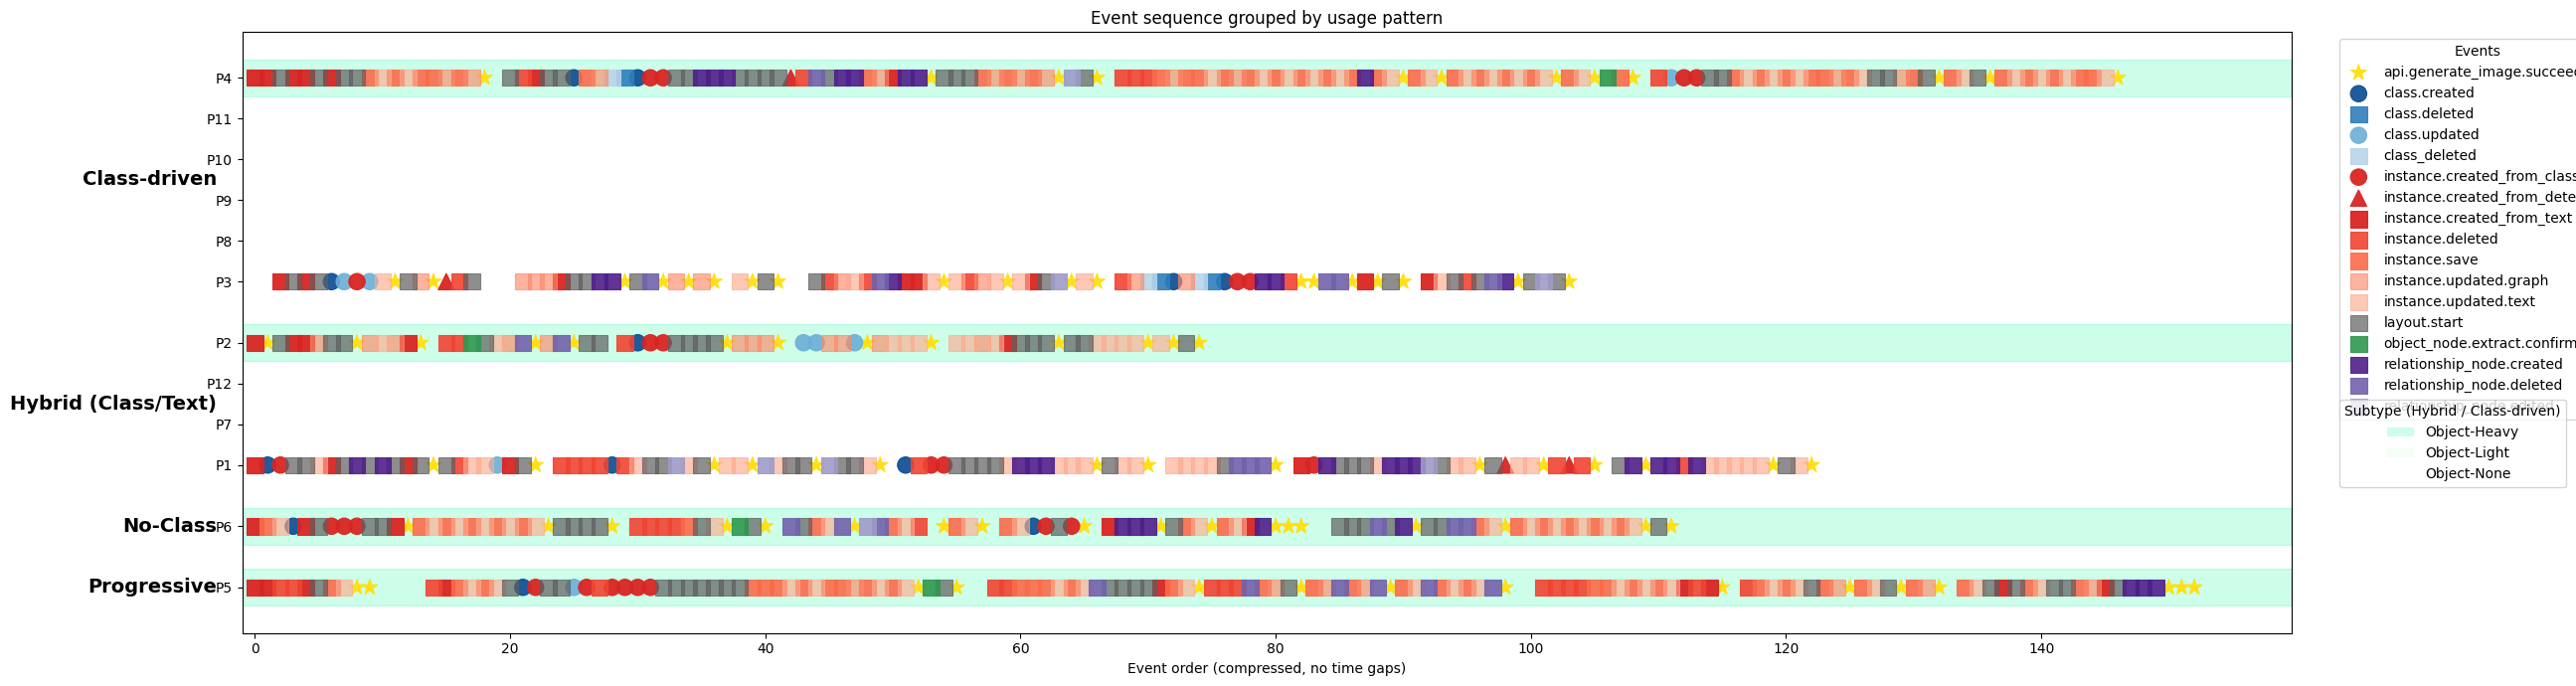

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ────────────────────────────────────────────────────────────────────────────
# 0) 준비: 시간 정렬 + 순서 인덱스(간격 제거)
# ────────────────────────────────────────────────────────────────────────────
df = df_all.copy()

if "timestamp" in df.columns:
    if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
        df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values(["id_group", "timestamp"]).copy()
else:
    # timestamp가 없으면 원래 순서대로 id_group 내에서 정렬
    df = df.sort_values(["id_group"]).copy()

df["seq_idx"] = df.groupby("id_group").cumcount()

# ────────────────────────────────────────────────────────────────────────────
# 1) 상위 그룹(전략) 매핑  ← 네가 쓰던 것 그대로
# ────────────────────────────────────────────────────────────────────────────
group_map = {
    3: "Class-driven",
    4: "Class-driven",
    8: "Class-driven",
    9: "Class-driven",
    10: "Class-driven",
    11: "Class-driven",
    1: "Hybrid (Class/Text)",
    2: "Hybrid (Class/Text)",
    7: "Hybrid (Class/Text)",
    12: "Hybrid (Class/Text)",
    5: "Progressive",
    6: "No-Class",
}
df["group"] = df["id_group"].map(group_map)

# ────────────────────────────────────────────────────────────────────────────
# 2) object 사용량으로 Hybrid/Class-driven을 서브타입 분기 (Heavy / Light / None)
#    - 같은 상위그룹 내에서 분위수 기준으로 나눔
# ────────────────────────────────────────────────────────────────────────────
obj_cnt = df[df["event"] == "object_node.extract.confirmed"].groupby("id_group").size()
obj_cnt = obj_cnt.reindex(sorted(df["id_group"].unique()), fill_value=0)

tmp = pd.DataFrame({"group": pd.Series(group_map), "obj_cnt": obj_cnt}).dropna(
    subset=["group"]
)

subtype = {}
for g, sub in tmp.groupby("group"):
    # No-Class는 서브타입 구분 안 함
    if g not in ["Hybrid (Class/Text)", "Class-driven", "No-Class", "Progressive"]:
        for pid in sub.index:
            subtype[pid] = f"{g}"
        continue

    # None
    none_ids = sub.index[sub["obj_cnt"] == 0]
    for pid in none_ids:
        subtype[pid] = f"{g}-Object-None"

    # Heavy/Light (0 초과만)
    pos = sub[sub["obj_cnt"] > 0]["obj_cnt"]
    if len(pos) > 0:
        thr = np.quantile(pos, 0.67) if len(pos) >= 3 else pos.median()
        for pid, cnt in pos.items():
            subtype[pid] = f"{g}-Object-Heavy" if cnt >= thr else f"{g}-Object-Light"

# 맵핑 붙이기
df["subtype"] = df["id_group"].map(subtype).fillna(df["group"])


# 기본값 보정 함수
def style_for(ev):
    marker = marker_map.get(ev, "s")
    alpha = alpha_map.get(ev, 0.9)
    edge = 1  # edge_map.get(ev, 'k' if ev.startswith('instance.created_') else 'none')
    lw = 0.8 if edge != "none" else 0
    return marker, alpha, _, lw


# ────────────────────────────────────────────────────────────────────────────
# 4) y축 구성 (그룹 내부 정렬: Heavy → Light → None, 동률은 obj_cnt 내림차순 → id)
# ────────────────────────────────────────────────────────────────────────────
group_order = [
    "Class-driven",
    "Hybrid (Class/Text)",
    "No-Class",
    "Progressive",
]  # 원하는 순서
group_order.reverse()

# 서브타입 우선순위
prio = {"Object-Heavy": 2, "Object-Light": 1, "Object-None": 0}


def subtype_bucket(pid):
    """서브타입 라벨에서 버킷만 추출 (No-Class는 None 취급)"""
    st = subtype.get(pid, group_map.get(pid, ""))
    if "Object-Heavy" in st:
        return "Object-Heavy"
    if "Object-Light" in st:
        return "Object-Light"
    if "Object-None" in st:
        return "Object-None"
    return "Object-None"  # No-Class 포함


def sort_key(pid):
    bucket = subtype_bucket(pid)
    return (prio.get(bucket, 3), -int(obj_cnt.get(pid, 0)), int(pid))


rows = []
y = 0
group_centers = {}
yticks, ylabels = [], []

for g in group_order:
    # 이 그룹의 멤버 수집
    members = [pid for pid, gg in group_map.items() if gg == g]
    if not members:
        continue

    # 버킷 우선 정렬
    members_sorted = sorted(members, key=sort_key)

    start_y = y
    for pid in members_sorted:
        rows.append((pid, y))
        yticks.append(y)
        short = subtype.get(pid, g).replace("Class-driven-", "").replace("Hybrid-", "")
        ylabels.append(f"P{pid}")
        y += 1
    group_centers[g] = (start_y + y - 1) / 2
    y += 0.5  # 그룹 간 빈 줄

# id→y 매핑 업데이트 및 y축 값 부여
id_to_y = dict(rows)
df["y_axis"] = df["id_group"].map(id_to_y)

# ────────────────────────────────────────────────────────────────────────────
# 5) 플롯
# ────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(26, 7))

# (a) 서브타입 하이라이트 밴드 (Hybrid/Class-driven만)
for pid, yy in id_to_y.items():
    st = subtype.get(pid, group_map.get(pid, ""))
    if "Object-Heavy" in st:
        ax.axhspan(yy - 0.45, yy + 0.45, color="mediumspringgreen", alpha=0.2, zorder=0)
    elif "Object-Light" in st:
        ax.axhspan(yy - 0.45, yy + 0.45, color="palegreen", alpha=0.1, zorder=0)
    elif "Object-None" in st:
        ax.axhspan(yy - 0.45, yy + 0.45, color="gainsboro", alpha=0.0, zorder=0)

# (b) 이벤트 점
for ev in event_types:
    m = df["event"] == ev
    marker, aa, edge, lw = style_for(ev)
    ax.scatter(
        df.loc[m, "seq_idx"],
        df.loc[m, "y_axis"],
        c=[event_to_color[ev]] * m.sum(),
        marker=marker,
        s=140,
        alpha=aa,
        linewidths=lw,
        label=ev if ev not in ax.get_legend_handles_labels()[1] else None,
    )

# (c) y축: 참가자
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)

# (d) 왼쪽에 상위 그룹 라벨
for g, cy in group_centers.items():
    ax.text(-3, cy, g, ha="right", va="center", fontsize=14, fontweight="bold")

ax.set_xlabel("Event order (compressed, no time gaps)")
# ax.set_ylabel("Participants (subtype in brackets)")
ax.set_title("Event sequence grouped by usage pattern")

# (e) 범례: 이벤트 + 서브타입
event_legend = ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Events")
ax.add_artist(event_legend)

sub_legend = [
    Patch(
        facecolor="mediumspringgreen", alpha=0.2, edgecolor="none", label="Object-Heavy"
    ),
    Patch(facecolor="palegreen", alpha=0.1, edgecolor="none", label="Object-Light"),
    Patch(facecolor="gainsboro", alpha=0, edgecolor="none", label="Object-None"),
]
ax.legend(
    handles=sub_legend,
    title="Subtype (Hybrid / Class-driven)",
    bbox_to_anchor=(1.02, 0.40),
    loc="upper left",
)
plt.xlim(left=-1)

plt.tight_layout()
plt.show()

In [13]:
# 관심 이벤트 목록
target_events = [
    "instance.created_from_class",
    "instance.created_from_text",
    "instance.created_from_detection",
]

# id_group별 이벤트 개수 집계 (pivot)
counts = (
    df[df["event"].isin(target_events)]
    .groupby(["id_group", "event"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=target_events, fill_value=0)  # 순서 고정
)

# 총합 및 비율 계산
counts["total"] = counts.sum(axis=1)
counts["class_ratio"] = counts["instance.created_from_class"] / counts["total"].replace(
    0, np.nan
)

# 보기 좋게 reset_index
result = counts.reset_index()

result.sort_values(by=["class_ratio"], inplace=True, ascending=False)
result

event,id_group,instance.created_from_class,instance.created_from_text,instance.created_from_detection,total,class_ratio
5,6,5,5,0,10,0.500000
4,5,6,9,0,15,0.400000
0,1,4,5,2,11,0.363636
3,4,4,7,1,12,0.333333
1,2,2,5,0,7,0.285714
2,3,3,8,1,12,0.250000


In [14]:
result.sort_values(
    by=["instance.created_from_class", "class_ratio"], inplace=True, ascending=False
)
result

event,id_group,instance.created_from_class,instance.created_from_text,instance.created_from_detection,total,class_ratio
4,5,6,9,0,15,0.400000
5,6,5,5,0,10,0.500000
0,1,4,5,2,11,0.363636
3,4,4,7,1,12,0.333333
2,3,3,8,1,12,0.250000
1,2,2,5,0,7,0.285714
